# Imports

In [1]:
import time
from dataclasses import dataclass, replace
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import cho_factor, cho_solve
from scipy.interpolate import PchipInterpolator
from scipy.stats import norm

# Model Parameters

In [2]:
@dataclass(frozen=True)
class CIRParameters:
    kappa: float
    theta: float
    xi: float


@dataclass(frozen=True)
class SIRLSVParameters:
    s0: float = 1.0
    v0: float = 0.1024

    rd0: float = 0.02
    rf0: float = 0.01

    variance: CIRParameters = CIRParameters(
        kappa=1.5768,
        theta=0.0484,
        xi=0.5751,
    )

    domestic_rate: CIRParameters = CIRParameters(
        kappa=0.30,
        theta=0.02,
        xi=0.02,
    )

    foreign_rate: CIRParameters = CIRParameters(
        kappa=0.30,
        theta=0.015,
        xi=0.02,
    )

    rho_sv: float = -0.70
    rho_sd: float = -0.30
    rho_sf: float = 0.30
    rho_df: float = 0.50

    # CIR++ deterministic shifts
    h_d: Callable[[float], float] = lambda t: 0.02
    h_f: Callable[[float], float] = lambda t: 0.01


@dataclass(frozen=True)
class RKHSParameters:
    n_centres: int = 32
    bandwidth: float = 0.05
    regularization: float = 1e-6
    chunk_size: int = 20_000
    jitter: float = 1e-12


@dataclass(frozen=True)
class SimulationParameters:
    maturity: float = 1.0
    n_steps: int = 100
    n_particles: int = 10_000
    seed: int = 42

    leverage_min: float = 0.05
    leverage_max: float = 5.00

    conditional_floor: float = 1e-8
    gamma_floor: float = 1e-10

    include_rate_correction: bool = True

# Checking correlation matrix

In [3]:
def correlation_matrix(params: SIRLSVParameters) -> np.ndarray:
    corr = np.array(
        [
            [1.0,           params.rho_sd, params.rho_sf, params.rho_sv],
            [params.rho_sd, 1.0,           params.rho_df, 0.0],
            [params.rho_sf, params.rho_df, 1.0,           0.0],
            [params.rho_sv, 0.0,           0.0,           1.0],
        ],
        dtype=float,
    )

    eigenvalues = np.linalg.eigvalsh(corr)

    if eigenvalues.min() <= 0:
        raise ValueError(
            "La matrice de corrélation n'est pas définie positive. "
            f"Valeurs propres : {eigenvalues}"
        )

    return corr


model_params = SIRLSVParameters()
corr = correlation_matrix(model_params)

print("Matrice de corrélation :")
print(corr)

print("\nValeurs propres :")
print(np.linalg.eigvalsh(corr))

Matrice de corrélation :
[[ 1.  -0.3  0.3 -0.7]
 [-0.3  1.   0.5  0. ]
 [ 0.3  0.5  1.   0. ]
 [-0.7  0.   0.   1. ]]

Valeurs propres :
[0.063861   0.66195119 1.5        1.77418781]


# Synthetic Market surface

In [4]:
@dataclass(frozen=True)
class SyntheticMarket:
    s0: float = 1.0
    base_vol: float = 0.30

    skew: float = -0.20
    curvature: float = 0.15
    term_structure: float = 0.03

    rd_bar: float = 0.02
    rf_bar: float = 0.01

    def sigma_dupire(self, t, s):
        s = np.asarray(s, dtype=float)

        log_moneyness = np.log(
            np.maximum(s, 1e-12) / self.s0
        )

        vol = self.base_vol * (
            1.0
            + self.skew * log_moneyness
            + self.curvature * log_moneyness**2
            + self.term_structure * np.sqrt(max(t, 0.0))
        )

        return np.clip(vol, 0.05, 1.50)

    def call_strike_gamma(self, t, strike):
        """
        Proxy Black-Scholes de d²C/dK².
        """
        strike = np.asarray(strike, dtype=float)
        tau = max(float(t), 1e-6)

        sigma = self.sigma_dupire(tau, strike)

        forward = (
            self.s0
            * np.exp((self.rd_bar - self.rf_bar) * tau)
        )

        d2 = (
            np.log(forward / np.maximum(strike, 1e-12))
            - 0.5 * sigma**2 * tau
        ) / (sigma * np.sqrt(tau))

        discount = np.exp(-self.rd_bar * tau)

        gamma = (
            discount
            * norm.pdf(d2)
            / (
                np.maximum(strike, 1e-12)
                * sigma
                * np.sqrt(tau)
            )
        )

        return np.maximum(gamma, 1e-12)


market = SyntheticMarket()

# RKHS Kernel

In [5]:
def gaussian_kernel(
    x: np.ndarray,
    z: np.ndarray,
    bandwidth: float,
) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    z = np.asarray(z, dtype=float).reshape(1, -1)

    scaled_distance = (x - z) / bandwidth

    return np.exp(-0.5 * scaled_distance**2)


def select_quantile_centres(
    spot: np.ndarray,
    n_centres: int,
) -> np.ndarray:
    probabilities = np.linspace(
        0.005,
        0.995,
        n_centres,
    )

    centres = np.quantile(spot, probabilities)

    # Évite des centres exactement identiques
    centres = np.unique(centres)

    if centres.size < 2:
        spread = max(abs(float(spot[0])) * 1e-4, 1e-6)
        centres = np.array(
            [spot[0] - spread, spot[0] + spread]
        )

    return centres

# RKHS regression

In [6]:
@dataclass
class RKHSFit:
    centres: np.ndarray
    coefficients: np.ndarray
    bandwidth: float

    condition_number: float
    timings: dict

    def predict(self, x: np.ndarray) -> np.ndarray:
        kernel_matrix = gaussian_kernel(
            x,
            self.centres,
            self.bandwidth,
        )

        return kernel_matrix @ self.coefficients


def fit_multioutput_rkhs(
    spot: np.ndarray,
    targets: np.ndarray,
    params: RKHSParameters,
) -> RKHSFit:
    start_total = time.perf_counter()

    spot = np.asarray(spot, dtype=float)
    targets = np.asarray(targets, dtype=float)

    if targets.ndim == 1:
        targets = targets[:, None]

    n_particles = spot.size

    # 1. Sélection des centres
    start_centres = time.perf_counter()

    centres = select_quantile_centres(
        spot,
        params.n_centres,
    )

    centres_time = (
        time.perf_counter() - start_centres
    )

    # 2. Matrice de Gram de la base RKHS
    start_regularization = time.perf_counter()

    kernel_centres = gaussian_kernel(
        centres,
        centres,
        params.bandwidth,
    )

    kernel_centres = 0.5 * (
        kernel_centres + kernel_centres.T
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        kernel_centres
    )

    max_eigenvalue = max(
        float(eigenvalues.max()),
        1e-16,
    )

    relative_tolerance = 1e-10

    retained = (
        eigenvalues
        > relative_tolerance * max_eigenvalue
    )

    if retained.sum() == 0:
        raise RuntimeError(
            "Toutes les directions RKHS ont été supprimées."
        )

    retained_eigenvalues = eigenvalues[retained]
    retained_eigenvectors = eigenvectors[:, retained]

    # B = U Lambda^{-1/2}
    whitening_matrix = (
        retained_eigenvectors
        / np.sqrt(retained_eigenvalues)[None, :]
    )

    effective_rank = retained.sum()

    regularization_time = (
        time.perf_counter() - start_regularization
    )

    # 3. Construction de la matrice de Gram blanchie
    whitened_gram = np.zeros(
        (effective_rank, effective_rank),
        dtype=float,
    )

    rhs = np.zeros(
        (effective_rank, targets.shape[1]),
        dtype=float,
    )

    start_gram = time.perf_counter()

    for start in range(
        0,
        n_particles,
        params.chunk_size,
    ):
        stop = min(
            start + params.chunk_size,
            n_particles,
        )

        kernel_chunk = gaussian_kernel(
            spot[start:stop],
            centres,
            params.bandwidth,
        )

        whitened_features = (
            kernel_chunk @ whitening_matrix
        )

        whitened_gram += (
            whitened_features.T
            @ whitened_features
        )

        rhs += (
            whitened_features.T
            @ targets[start:stop]
        )

    gram_time = time.perf_counter() - start_gram

    # 4. Système régularisé dans la base orthonormale
    system_matrix = (
        whitened_gram
        + n_particles
        * params.regularization
        * np.eye(effective_rank)
    )

    numerical_jitter = (
        params.jitter
        * max(
            np.trace(system_matrix)
            / effective_rank,
            1.0,
        )
    )

    system_matrix += (
        numerical_jitter
        * np.eye(effective_rank)
    )

    # 5. Résolution
    start_solve = time.perf_counter()

    try:
        factor = cho_factor(
            system_matrix,
            lower=True,
            check_finite=False,
        )

        whitened_coefficients = cho_solve(
            factor,
            rhs,
            check_finite=False,
        )

    except np.linalg.LinAlgError:
        whitened_coefficients = np.linalg.lstsq(
            system_matrix,
            rhs,
            rcond=1e-12,
        )[0]

    solve_time = time.perf_counter() - start_solve

    # Retour dans la base originale
    coefficients = (
        whitening_matrix
        @ whitened_coefficients
    )

    condition_number = np.linalg.cond(
        system_matrix
    )

    total_time = time.perf_counter() - start_total

    timings = {
        "centre_selection": centres_time,
        "gram_construction": gram_time,
        "regularization": regularization_time,
        "linear_solve": solve_time,
        "rkhs_total": total_time,
        "effective_rank": effective_rank,
    }

    return RKHSFit(
        centres=centres,
        coefficients=coefficients,
        bandwidth=params.bandwidth,
        condition_number=condition_number,
        timings=timings,
    )

# Stochastic rates correction

In [7]:
def stochastic_rate_correction(
    spot: np.ndarray,
    domestic_rate: np.ndarray,
    foreign_rate: np.ndarray,
    domestic_discount: np.ndarray,
    evaluation_points: np.ndarray,
    rd_bar: float,
    rf_bar: float,
    chunk_size: int = 20_000,
) -> np.ndarray:
    """
    Calcule E[Q_t(x)] par Monte Carlo pour chaque x.
    """
    evaluation_points = np.asarray(
        evaluation_points,
        dtype=float,
    )

    correction_sum = np.zeros_like(
        evaluation_points,
        dtype=float,
    )

    n_particles = spot.size

    for start in range(0, n_particles, chunk_size):
        stop = min(start + chunk_size, n_particles)

        s = spot[start:stop, None]
        rd = domestic_rate[start:stop, None]
        rf = foreign_rate[start:stop, None]
        discount = domestic_discount[start:stop, None]

        x = evaluation_points[None, :]

        payoff = np.maximum(s - x, 0.0)
        indicator = s >= x

        first_term = (
            discount
            * (rf - rf_bar)
            * payoff
        )

        second_term = (
            x
            * discount
            * indicator
            * (
                (rd - rd_bar)
                - (rf - rf_bar)
            )
        )

        correction_sum += np.sum(
            first_term - second_term,
            axis=0,
        )

    return correction_sum / n_particles

# Simulation results

In [8]:
@dataclass
class SIRLSVResult:
    terminal_spot: np.ndarray
    terminal_variance: np.ndarray
    terminal_domestic_rate: np.ndarray
    terminal_foreign_rate: np.ndarray
    terminal_discount: np.ndarray

    leverage_history: pd.DataFrame
    timing_history: pd.DataFrame

    total_runtime: float

# SIR-LSV Engine calibrated using RKHS

In [9]:
def simulate_calibrated_sir_lsv(
    model: SIRLSVParameters,
    rkhs: RKHSParameters,
    simulation: SimulationParameters,
    market: SyntheticMarket,
) -> SIRLSVResult:
    total_start = time.perf_counter()

    rng = np.random.default_rng(simulation.seed)

    n = simulation.n_particles
    dt = simulation.maturity / simulation.n_steps
    sqrt_dt = np.sqrt(dt)

    corr = correlation_matrix(model)
    cholesky = np.linalg.cholesky(corr)

    # États initiaux
    spot = np.full(n, model.s0, dtype=float)
    variance = np.full(n, model.v0, dtype=float)

    gd0 = max(model.rd0 - model.h_d(0.0), 0.0)
    gf0 = max(model.rf0 - model.h_f(0.0), 0.0)

    gd = np.full(n, gd0, dtype=float)
    gf = np.full(n, gf0, dtype=float)

    domestic_rate = gd + model.h_d(0.0)
    foreign_rate = gf + model.h_f(0.0)

    domestic_discount = np.ones(n, dtype=float)

    initial_sigma = market.sigma_dupire(0.0, model.s0)

    leverage_grid = np.array(
        [0.5 * model.s0, 1.5 * model.s0]
    )

    leverage_values = np.full(
        2,
        initial_sigma / np.sqrt(model.v0),
    )

    leverage_records = []
    timing_records = []

    var_params = model.variance
    rd_params = model.domestic_rate
    rf_params = model.foreign_rate

    for step in range(1, simulation.n_steps + 1):
        step_start = time.perf_counter()

        previous_time = (step - 1) * dt
        current_time = step * dt

        start_particles = time.perf_counter()

        # Leverage aux positions des particules
        leverage = np.interp(
            spot,
            leverage_grid,
            leverage_values,
            left=leverage_values[0],
            right=leverage_values[-1],
        )

        independent_normals = rng.standard_normal((n, 4))
        correlated_normals = independent_normals @ cholesky.T

        z_s = correlated_normals[:, 0]
        z_d = correlated_normals[:, 1]
        z_f = correlated_normals[:, 2]
        z_v = correlated_normals[:, 3]

        variance_positive = np.maximum(variance, 0.0)
        gd_positive = np.maximum(gd, 0.0)
        gf_positive = np.maximum(gf, 0.0)

        old_spot = spot.copy()
        old_variance = variance_positive.copy()
        old_domestic_rate = domestic_rate.copy()
        old_foreign_rate = foreign_rate.copy()

        # Spot
        spot = (
            old_spot
            + (old_domestic_rate - old_foreign_rate)
            * old_spot
            * dt
            + leverage
            * np.sqrt(old_variance)
            * old_spot
            * sqrt_dt
            * z_s
        )

        spot = np.maximum(spot, 1e-10)

        # Discount factor domestique
        domestic_discount *= np.exp(
            -old_domestic_rate * dt
        )

        # Taux domestique, full truncation Euler
        gd = (
            gd
            + rd_params.kappa
            * (rd_params.theta - gd_positive)
            * dt
            + rd_params.xi
            * np.sqrt(gd_positive)
            * sqrt_dt
            * z_d
        )

        gd = np.maximum(gd, 0.0)

        # Taux étranger sous la mesure domestique
        foreign_quanto_drift = (
            -model.rho_sf
            * rf_params.xi
            * np.sqrt(gf_positive)
            * leverage
            * np.sqrt(old_variance)
        )

        gf = (
            gf
            + (
                rf_params.kappa
                * (rf_params.theta - gf_positive)
                + foreign_quanto_drift
            )
            * dt
            + rf_params.xi
            * np.sqrt(gf_positive)
            * sqrt_dt
            * z_f
        )

        gf = np.maximum(gf, 0.0)

        # Variance
        variance = (
            variance
            + var_params.kappa
            * (var_params.theta - variance_positive)
            * dt
            + var_params.xi
            * np.sqrt(variance_positive)
            * sqrt_dt
            * z_v
        )

        variance = np.maximum(variance, 0.0)

        domestic_rate = gd + model.h_d(current_time)
        foreign_rate = gf + model.h_f(current_time)

        particle_time = (
            time.perf_counter() - start_particles
        )

        # Targets multi-output
        targets = np.column_stack(
            [
                domestic_discount,
                domestic_discount * variance,
            ]
        )

        rkhs_fit = fit_multioutput_rkhs(
            spot,
            targets,
            rkhs,
        )

        centres = rkhs_fit.centres
        conditional_moments = rkhs_fit.predict(centres)

        conditional_discount = np.maximum(
            conditional_moments[:, 0],
            simulation.conditional_floor,
        )

        conditional_discounted_variance = np.maximum(
            conditional_moments[:, 1],
            simulation.conditional_floor,
        )

        conditional_variance = (
            conditional_discounted_variance
            / conditional_discount
        )

        conditional_variance = np.maximum(
            conditional_variance,
            simulation.conditional_floor,
        )

                # =====================================================
        # CALIBRATION DE LA LEVERAGE FUNCTION
        # =====================================================

        start_correction = time.perf_counter()

        # Compatible avec :
        # - SyntheticMarket où rd_bar/rf_bar sont des nombres ;
        # - ReferenceSIRHestonMarket où ce sont des fonctions.
        rd_bar_t = (
            market.rd_bar(current_time)
            if callable(market.rd_bar)
            else float(market.rd_bar)
        )

        rf_bar_t = (
            market.rf_bar(current_time)
            if callable(market.rf_bar)
            else float(market.rf_bar)
        )

        if simulation.include_rate_correction:
            rate_correction = (
                stochastic_rate_correction(
                    spot=spot,
                    domestic_rate=domestic_rate,
                    foreign_rate=foreign_rate,
                    domestic_discount=(
                        domestic_discount
                    ),
                    evaluation_points=centres,
                    rd_bar=rd_bar_t,
                    rf_bar=rf_bar_t,
                    chunk_size=rkhs.chunk_size,
                )
            )
        else:
            rate_correction = np.zeros_like(
                centres
            )

        correction_time = (
            time.perf_counter()
            - start_correction
        )

        # Surface de Dupire du marché
        sigma_dupire = market.sigma_dupire(
            current_time,
            centres,
        )

        # Gamma d²C/dK² du marché
        call_gamma = market.call_strike_gamma(
            current_time,
            centres,
        )

        call_gamma = np.maximum(
            call_gamma,
            simulation.gamma_floor,
        )

        gamma_denominator = (
            0.5
            * np.maximum(centres, 1e-10) ** 2
            * call_gamma
        )

        # Correction stochastique de taux :
        #
        # E[Q_t(x)] / (0.5 x² C_KK)
        rate_adjustment = (
            rate_correction
            / np.maximum(
                gamma_denominator,
                simulation.gamma_floor,
            )
        )

        # Ne pas appliquer de maximum immédiatement :
        # on veut détecter les valeurs négatives.
        raw_adjusted_local_variance = (
            sigma_dupire**2
            + rate_adjustment
        )

        raw_leverage_squared = (
            raw_adjusted_local_variance
            / np.maximum(
                conditional_variance,
                simulation.conditional_floor,
            )
        )

        # Leverage brute, uniquement pour diagnostic
        raw_leverage = np.full_like(
            raw_leverage_squared,
            np.nan,
            dtype=float,
        )

        positive_raw_leverage = (
            np.isfinite(raw_leverage_squared)
            & (raw_leverage_squared > 0.0)
        )

        raw_leverage[
            positive_raw_leverage
        ] = np.sqrt(
            raw_leverage_squared[
                positive_raw_leverage
            ]
        )

        # =====================================================
        # IDENTIFICATION DES POINTS FIABLES
        # =====================================================

        relative_gamma = (
            call_gamma
            / max(
                float(call_gamma.max()),
                1e-16,
            )
        )

        reliable = (
            np.isfinite(
                raw_adjusted_local_variance
            )
            & (
                raw_adjusted_local_variance
                > 0.0
            )
            & np.isfinite(
                conditional_variance
            )
            & (
                conditional_variance
                > simulation.conditional_floor
            )
            & (relative_gamma > 1e-6)
        )

        if reliable.sum() < 2:
            raise RuntimeError(
                "Pas assez de points fiables "
                f"pour calibrer la leverage à "
                f"t={current_time:.4f}. "
                f"Points fiables : "
                f"{reliable.sum()}/{centres.size}"
            )

        # =====================================================
        # INTERPOLATION DEPUIS LA RÉGION FIABLE
        # =====================================================

        reliable_spots = centres[reliable]

        reliable_leverages = np.sqrt(
            raw_adjusted_local_variance[
                reliable
            ]
            / conditional_variance[reliable]
        )

        reliable_order = np.argsort(
            reliable_spots
        )

        reliable_spots = (
            reliable_spots[reliable_order]
        )

        reliable_leverages = (
            reliable_leverages[
                reliable_order
            ]
        )

        # np.interp réalise une extrapolation constante
        # dans les ailes.
        new_leverage = np.interp(
            centres,
            reliable_spots,
            reliable_leverages,
            left=reliable_leverages[0],
            right=reliable_leverages[-1],
        )

        # Le clipping reste une protection finale,
        # mais ne doit normalement plus être activé.
        new_leverage = np.clip(
            new_leverage,
            simulation.leverage_min,
            simulation.leverage_max,
        )

        # Centres triés pour l'interpolation au prochain pas
        order = np.argsort(centres)

        leverage_grid = centres[order]
        leverage_values = new_leverage[order]

        # =====================================================
        # SAUVEGARDE DES DIAGNOSTICS
        # =====================================================

        for index in order:
            leverage_records.append(
                {
                    "step": step,
                    "time": current_time,
                    "spot": centres[index],

                    "leverage": (
                        new_leverage[index]
                    ),

                    "raw_leverage": (
                        raw_leverage[index]
                    ),

                    "reliable_point": bool(
                        reliable[index]
                    ),

                    "conditional_variance": (
                        conditional_variance[index]
                    ),

                    "sigma_dupire": (
                        sigma_dupire[index]
                    ),

                    "call_gamma": (
                        call_gamma[index]
                    ),

                    "relative_gamma": (
                        relative_gamma[index]
                    ),

                    "gamma_denominator": (
                        gamma_denominator[index]
                    ),

                    "rate_correction": (
                        rate_correction[index]
                    ),

                    "rate_adjustment": (
                        rate_adjustment[index]
                    ),

                    "raw_adjusted_local_variance": (
                        raw_adjusted_local_variance[
                            index
                        ]
                    ),
                }
            )

        step_time = time.perf_counter() - step_start

        timing_records.append(
            {
                "step": step,
                "time": current_time,
                "particle_update": particle_time,
                **rkhs_fit.timings,
                "rate_correction": correction_time,
                "step_total": step_time,
                "condition_number": rkhs_fit.condition_number,
            }
        )

        for x, lev, m_v in zip(
            leverage_grid,
            leverage_values,
            conditional_variance[order],
        ):
            leverage_records.append(
                {
                    "step": step,
                    "time": current_time,
                    "spot": x,
                    "leverage": lev,
                    "conditional_variance": m_v,
                }
            )

    total_runtime = time.perf_counter() - total_start

    return SIRLSVResult(
        terminal_spot=spot,
        terminal_variance=variance,
        terminal_domestic_rate=domestic_rate,
        terminal_foreign_rate=foreign_rate,
        terminal_discount=domestic_discount,
        leverage_history=pd.DataFrame(leverage_records),
        timing_history=pd.DataFrame(timing_records),
        total_runtime=total_runtime,
    )

# 1st Smoke test

In [10]:
model_params = SIRLSVParameters()

rkhs_params = RKHSParameters(
    n_centres=32,
    bandwidth=0.05,
    regularization=1e-6,
    chunk_size=10_000,
)

simulation_params = SimulationParameters(
    maturity=1.0,
    n_steps=100,
    n_particles=10_000,
    seed=42,
    include_rate_correction=False,
)

market = SyntheticMarket(
    s0=model_params.s0,
    rd_bar=model_params.rd0,
    rf_bar=model_params.rf0,
)

result = simulate_calibrated_sir_lsv(
    model=model_params,
    rkhs=rkhs_params,
    simulation=simulation_params,
    market=market,
)

print(f"Temps total : {result.total_runtime:.2f} secondes")
print()
print(result.timing_history.describe().T)

Temps total : 0.83 secondes

                   count           mean           std            min  \
step               100.0      50.500000     29.011492       1.000000   
time               100.0       0.505000      0.290115       0.010000   
particle_update    100.0       0.000954      0.000243       0.000787   
centre_selection   100.0       0.000403      0.000097       0.000318   
gram_construction  100.0       0.005577      0.000881       0.004433   
regularization     100.0       0.000418      0.000129       0.000129   
linear_solve       100.0       0.000093      0.000032       0.000072   
rkhs_total         100.0       0.006704      0.001002       0.005369   
effective_rank     100.0      27.590000      5.266811      10.000000   
rate_correction    100.0       0.000013      0.000004       0.000008   
step_total         100.0       0.008283      0.001138       0.006762   
condition_number   100.0  229107.172610  88584.902455  131585.199455   

                             25%  

In [11]:
model_params = SIRLSVParameters()

rkhs_params = RKHSParameters(
    n_centres=32,
    bandwidth=0.05,
    regularization=1e-6,
    chunk_size=10_000,
)

simulation_params = SimulationParameters(
    maturity=1.0,
    n_steps=100,
    n_particles=10_000,
    seed=42,
    include_rate_correction=True,
)

market = SyntheticMarket(
    s0=model_params.s0,
    rd_bar=model_params.rd0,
    rf_bar=model_params.rf0,
)

result = simulate_calibrated_sir_lsv(
    model=model_params,
    rkhs=rkhs_params,
    simulation=simulation_params,
    market=market,
)

print(f"Temps total : {result.total_runtime:.2f} secondes")
print()
print(result.timing_history.describe().T)

Temps total : 1.46 secondes

                   count           mean           std            min  \
step               100.0      50.500000     29.011492       1.000000   
time               100.0       0.505000      0.290115       0.010000   
particle_update    100.0       0.000935      0.000192       0.000797   
centre_selection   100.0       0.000401      0.000098       0.000332   
gram_construction  100.0       0.005733      0.000965       0.004304   
regularization     100.0       0.000501      0.000640       0.000177   
linear_solve       100.0       0.000091      0.000029       0.000070   
rkhs_total         100.0       0.006939      0.001412       0.005204   
effective_rank     100.0      27.590000      5.266811      10.000000   
rate_correction    100.0       0.006001      0.000724       0.004946   
step_total         100.0       0.014612      0.001938       0.012446   
condition_number   100.0  229314.266255  88474.140279  132496.103660   

                             25%  

In [12]:
def simulation_diagnostics(
    result,
    simulation_params,
):
    leverage = result.leverage_history["leverage"]
    conditional_variance = result.leverage_history[
        "conditional_variance"
    ]

    condition_numbers = result.timing_history[
        "condition_number"
    ]

    diagnostics = pd.Series(
        {
            "min_leverage": leverage.min(),
            "median_leverage": leverage.median(),
            "max_leverage": leverage.max(),

            "fraction_at_lower_bound": np.mean(
                np.isclose(
                    leverage,
                    simulation_params.leverage_min,
                )
            ),

            "fraction_at_upper_bound": np.mean(
                np.isclose(
                    leverage,
                    simulation_params.leverage_max,
                )
            ),

            "min_conditional_variance": (
                conditional_variance.min()
            ),

            "median_conditional_variance": (
                conditional_variance.median()
            ),

            "max_conditional_variance": (
                conditional_variance.max()
            ),

            "median_log10_condition": np.median(
                np.log10(condition_numbers)
            ),

            "max_log10_condition": np.max(
                np.log10(condition_numbers)
            ),

            "nan_count": (
                result.leverage_history
                .isna()
                .sum()
                .sum()
            ),
        }
    )

    return diagnostics


print(simulation_diagnostics(
    result,
    simulation_params,
))

min_leverage                       0.616929
median_leverage                    1.264649
max_leverage                       2.502447
fraction_at_lower_bound            0.000000
fraction_at_upper_bound            0.000000
min_conditional_variance           0.013604
median_conditional_variance        0.058907
max_conditional_variance           0.361466
median_log10_condition             5.308109
max_log10_condition                5.853569
nan_count                      28800.000000
dtype: float64


In [13]:
result_original = result

In [14]:
result_whitened = simulate_calibrated_sir_lsv(
    model=model_params,
    rkhs=rkhs_params,
    simulation=simulation_params,
    market=market,
)

In [15]:
conditioning_comparison = pd.DataFrame(
    {
        "original": np.log10(
            result_original
            .timing_history["condition_number"]
        ),
        "whitened": np.log10(
            result_whitened
            .timing_history["condition_number"]
        ),
    }
)

print(conditioning_comparison.describe())

         original    whitened
count  100.000000  100.000000
mean     5.335672    5.335672
std      0.140525    0.140525
min      5.122203    5.122203
25%      5.234287    5.234287
50%      5.308109    5.308109
75%      5.424845    5.424845
max      5.853569    5.853569


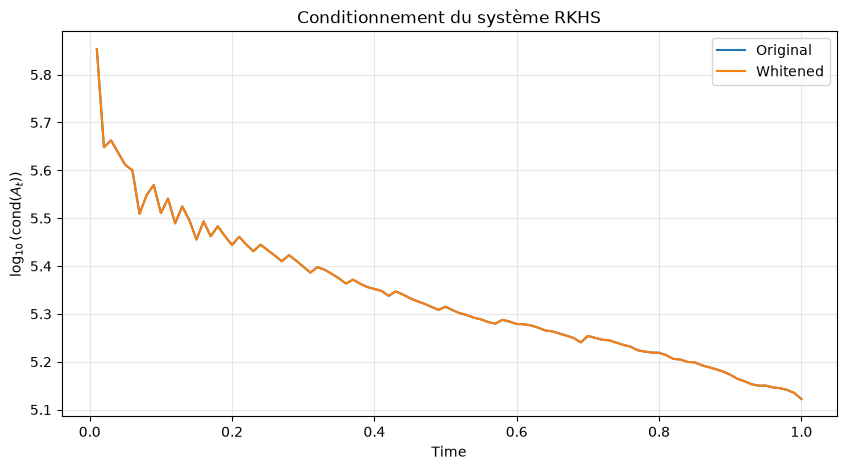

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    result_original.timing_history["time"],
    np.log10(
        result_original
        .timing_history["condition_number"]
    ),
    label="Original",
)

plt.plot(
    result_whitened.timing_history["time"],
    np.log10(
        result_whitened
        .timing_history["condition_number"]
    ),
    label="Whitened",
)

plt.xlabel("Time")
plt.ylabel(r"$\log_{10}(\mathrm{cond}(A_t))$")
plt.title("Conditionnement du système RKHS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
print(result_whitened.timing_history[
    "effective_rank"
].describe())

count    100.000000
mean      27.590000
std        5.266811
min       10.000000
25%       25.000000
50%       30.000000
75%       32.000000
max       32.000000
Name: effective_rank, dtype: float64


In [18]:
def terminal_comparison(
    original,
    whitened,
):
    variables = {
        "spot": (
            original.terminal_spot,
            whitened.terminal_spot,
        ),
        "variance": (
            original.terminal_variance,
            whitened.terminal_variance,
        ),
        "domestic_rate": (
            original.terminal_domestic_rate,
            whitened.terminal_domestic_rate,
        ),
        "foreign_rate": (
            original.terminal_foreign_rate,
            whitened.terminal_foreign_rate,
        ),
        "discount": (
            original.terminal_discount,
            whitened.terminal_discount,
        ),
    }

    records = []

    for name, (old, new) in variables.items():
        records.append(
            {
                "variable": name,
                "original_mean": old.mean(),
                "whitened_mean": new.mean(),
                "original_std": old.std(ddof=1),
                "whitened_std": new.std(ddof=1),
                "pathwise_rmse": np.sqrt(
                    np.mean((new - old) ** 2)
                ),
                "relative_mean_difference": (
                    abs(new.mean() - old.mean())
                    / max(abs(old.mean()), 1e-12)
                ),
            }
        )

    return pd.DataFrame(records)


print(terminal_comparison(
    result_original,
    result_whitened,
))

        variable  original_mean  whitened_mean  original_std  whitened_std  \
0           spot       1.012150       1.012150      0.314264      0.314264   
1       variance       0.061421       0.061421      0.081871      0.081871   
2  domestic_rate       0.025192       0.025192      0.000941      0.000941   
3   foreign_rate       0.013844       0.013844      0.000820      0.000820   
4       discount       0.977555       0.977555      0.000384      0.000384   

   pathwise_rmse  relative_mean_difference  
0            0.0                       0.0  
1            0.0                       0.0  
2            0.0                       0.0  
3            0.0                       0.0  
4            0.0                       0.0  


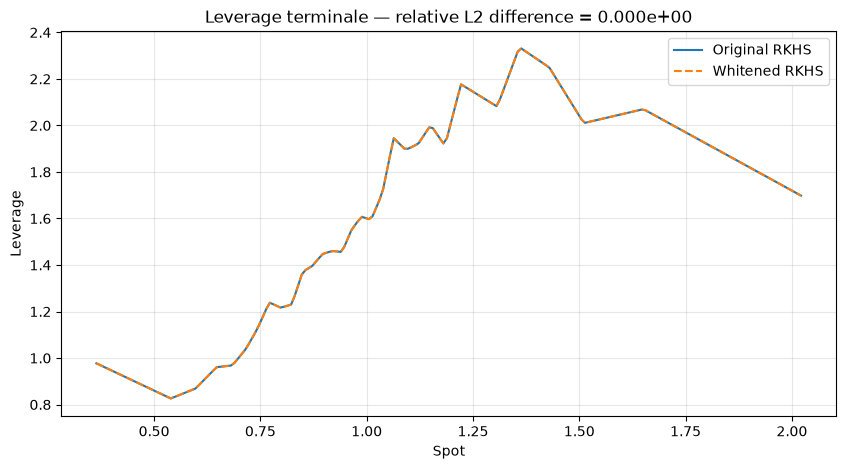

Erreur L2 relative : 0.000000e+00


In [19]:
def compare_final_leverage(
    original,
    whitened,
):
    final_step_original = int(
        original.leverage_history["step"].max()
    )

    final_step_whitened = int(
        whitened.leverage_history["step"].max()
    )

    old = original.leverage_history[
        original.leverage_history["step"]
        == final_step_original
    ].sort_values("spot")

    new = whitened.leverage_history[
        whitened.leverage_history["step"]
        == final_step_whitened
    ].sort_values("spot")

    lower = max(
        old["spot"].min(),
        new["spot"].min(),
    )

    upper = min(
        old["spot"].max(),
        new["spot"].max(),
    )

    common_grid = np.linspace(lower, upper, 200)

    old_leverage = np.interp(
        common_grid,
        old["spot"],
        old["leverage"],
    )

    new_leverage = np.interp(
        common_grid,
        new["spot"],
        new["leverage"],
    )

    relative_l2_error = (
        np.linalg.norm(new_leverage - old_leverage)
        / np.linalg.norm(old_leverage)
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        common_grid,
        old_leverage,
        label="Original RKHS",
    )

    plt.plot(
        common_grid,
        new_leverage,
        linestyle="--",
        label="Whitened RKHS",
    )

    plt.xlabel("Spot")
    plt.ylabel("Leverage")
    plt.title(
        "Leverage terminale — "
        f"relative L2 difference = "
        f"{relative_l2_error:.3e}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return relative_l2_error


leverage_difference = compare_final_leverage(
    result_original,
    result_whitened,
)

print(
    f"Erreur L2 relative : "
    f"{leverage_difference:.6e}"
)

# Checking terminal distributions

In [20]:
terminal_summary = pd.DataFrame(
    {
        "spot": result.terminal_spot,
        "variance": result.terminal_variance,
        "domestic_rate": result.terminal_domestic_rate,
        "foreign_rate": result.terminal_foreign_rate,
        "domestic_discount": result.terminal_discount,
    }
).describe()

terminal_summary

,spot,variance,domestic_rate,foreign_rate,domestic_discount
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.012150,0.061421,0.025192,0.013844,0.977555
std,0.314264,0.081871,0.000941,0.000820,0.000384
min,0.131579,0.000000,0.022313,0.011587,0.975700
25%,0.790503,0.007551,0.024524,0.013262,0.977312
50%,0.976460,0.029694,0.025131,0.013788,0.977575
75%,1.196260,0.082738,0.025797,0.014359,0.977824
max,3.583264,0.743431,0.029822,0.017681,0.978663


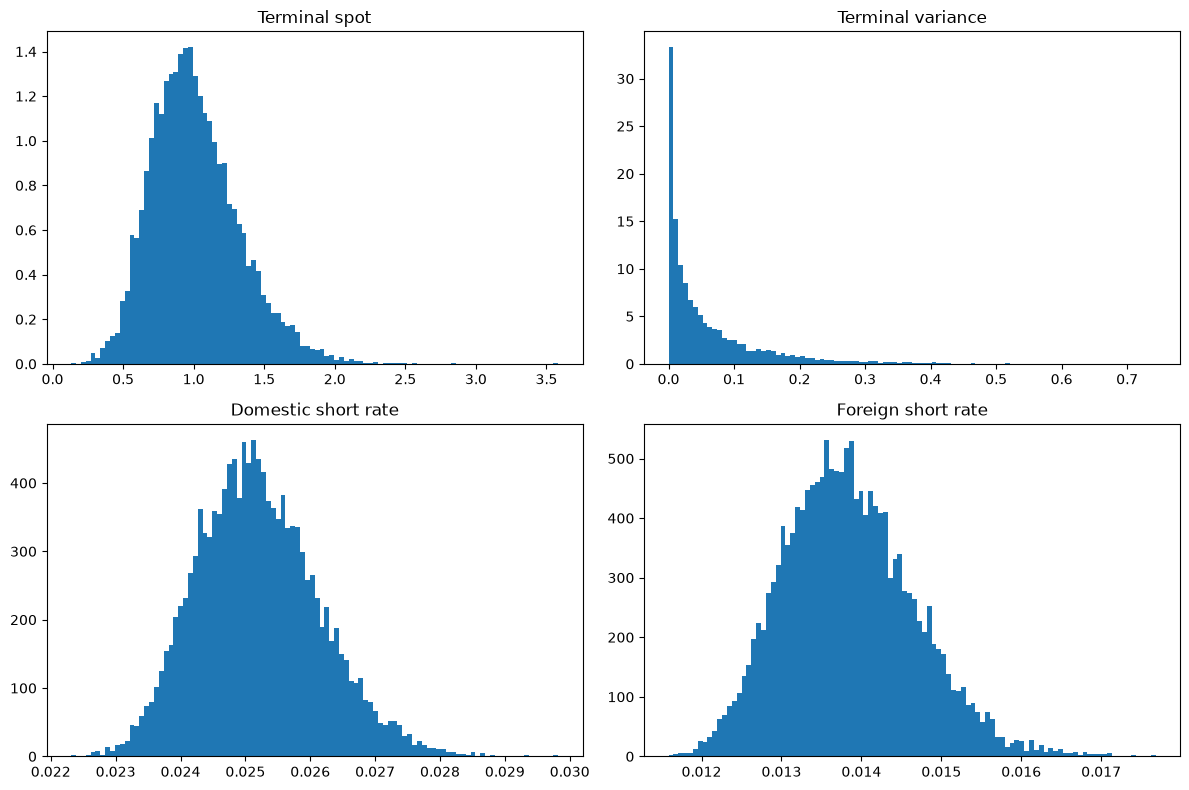

In [21]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes[0, 0].hist(
    result.terminal_spot,
    bins=100,
    density=True,
)
axes[0, 0].set_title("Terminal spot")

axes[0, 1].hist(
    result.terminal_variance,
    bins=100,
    density=True,
)
axes[0, 1].set_title("Terminal variance")

axes[1, 0].hist(
    result.terminal_domestic_rate,
    bins=100,
    density=True,
)
axes[1, 0].set_title("Domestic short rate")

axes[1, 1].hist(
    result.terminal_foreign_rate,
    bins=100,
    density=True,
)
axes[1, 1].set_title("Foreign short rate")

plt.tight_layout()
plt.show()

# Leverage surface

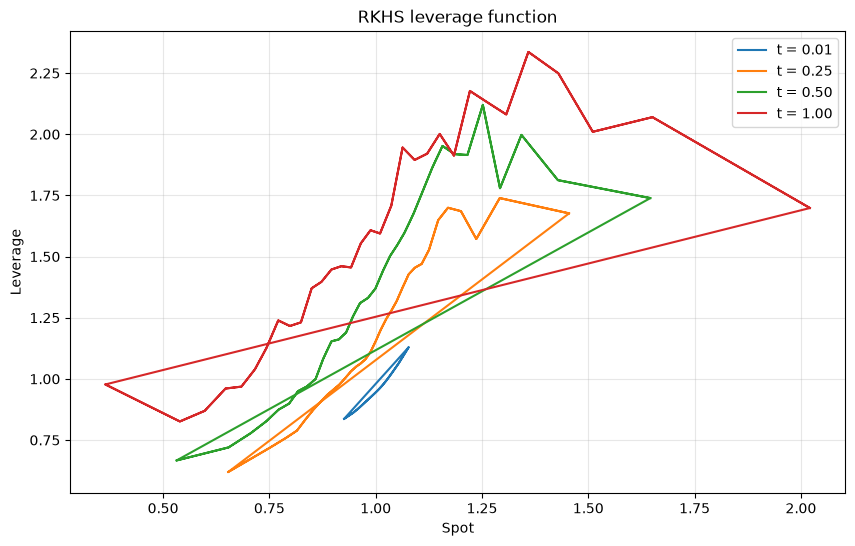

In [22]:
selected_steps = [
    1,
    simulation_params.n_steps // 4,
    simulation_params.n_steps // 2,
    simulation_params.n_steps,
]

plt.figure(figsize=(10, 6))

for step in selected_steps:
    step_data = result.leverage_history[
        result.leverage_history["step"] == step
    ]

    plt.plot(
        step_data["spot"],
        step_data["leverage"],
        label=f"t = {step_data['time'].iloc[0]:.2f}",
    )

plt.xlabel("Spot")
plt.ylabel("Leverage")
plt.title("RKHS leverage function")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Computation time detailed

,total_seconds
rate_correction,0.600058
gram_construction,0.573302
particle_update,0.093536
linear_solve,0.009062


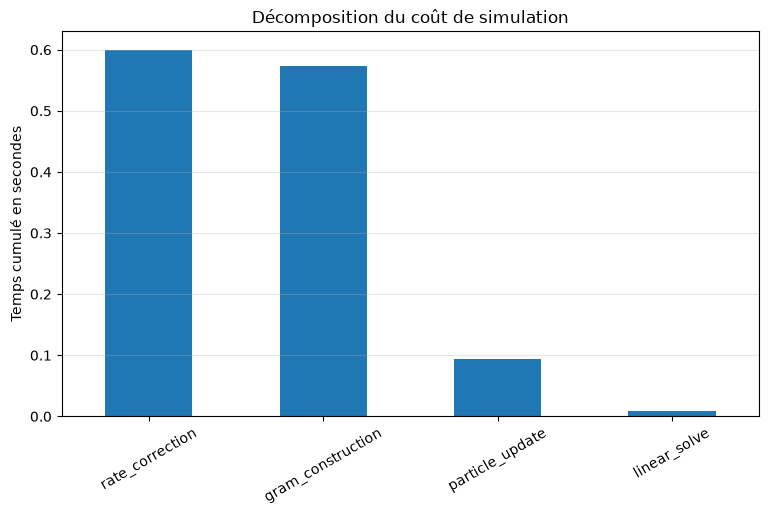

In [23]:
timing_columns = [
    "particle_update",
    "gram_construction",
    "linear_solve",
    "rate_correction",
]

timing_summary = (
    result.timing_history[timing_columns]
    .sum()
    .sort_values(ascending=False)
)

display(timing_summary.to_frame("total_seconds"))

timing_summary.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.ylabel("Temps cumulé en secondes")
plt.title("Décomposition du coût de simulation")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Benchmark function

In [24]:
def benchmark_particle_counts(
    particle_counts,
    base_model,
    base_rkhs,
    base_simulation,
    market,
):
    records = []

    for n_particles in particle_counts:
        print(f"Simulation avec N = {n_particles:,}")

        simulation = replace(
            base_simulation,
            n_particles=n_particles,
        )

        result = simulate_calibrated_sir_lsv(
            model=base_model,
            rkhs=base_rkhs,
            simulation=simulation,
            market=market,
        )

        timings = result.timing_history

        records.append(
            {
                "n_particles": n_particles,
                "n_steps": simulation.n_steps,
                "n_centres": base_rkhs.n_centres,
                "total_runtime": result.total_runtime,
                "particle_time": timings[
                    "particle_update"
                ].sum(),
                "gram_time": timings[
                    "gram_construction"
                ].sum(),
                "solve_time": timings[
                    "linear_solve"
                ].sum(),
                "correction_time": timings[
                    "rate_correction"
                ].sum(),
                "mean_condition_number": timings[
                    "condition_number"
                ].mean(),
                "terminal_spot_mean": (
                    result.terminal_spot.mean()
                ),
                "terminal_spot_std": (
                    result.terminal_spot.std(ddof=1)
                ),
                "terminal_variance_mean": (
                    result.terminal_variance.mean()
                ),
            }
        )

    return pd.DataFrame(records)

## Benchmark in N

In [25]:
benchmark_n = benchmark_particle_counts(
    particle_counts=[
        2_000,
        5_000,
        10_000,
        20_000,
    ],
    base_model=model_params,
    base_rkhs=rkhs_params,
    base_simulation=simulation_params,
    market=market,
)

benchmark_n

Simulation avec N = 2,000
Simulation avec N = 5,000
Simulation avec N = 10,000
Simulation avec N = 20,000


,n_particles,n_steps,n_centres,total_runtime,particle_time,gram_time,solve_time,correction_time,mean_condition_number,terminal_spot_mean,terminal_spot_std,terminal_variance_mean
0,2000,100,32,0.237163,0.021361,0.073883,0.005609,0.044877,233752.581993,1.006890,0.313542,0.060987
1,5000,100,32,0.830926,0.051750,0.315195,0.008175,0.314480,229559.774156,1.014656,0.318499,0.061090
2,10000,100,32,1.416131,0.090375,0.558289,0.009053,0.581372,229314.266255,1.012150,0.314264,0.061421
3,20000,100,32,2.800553,0.193765,1.186126,0.009106,1.193040,226371.189657,1.011015,0.313256,0.061630


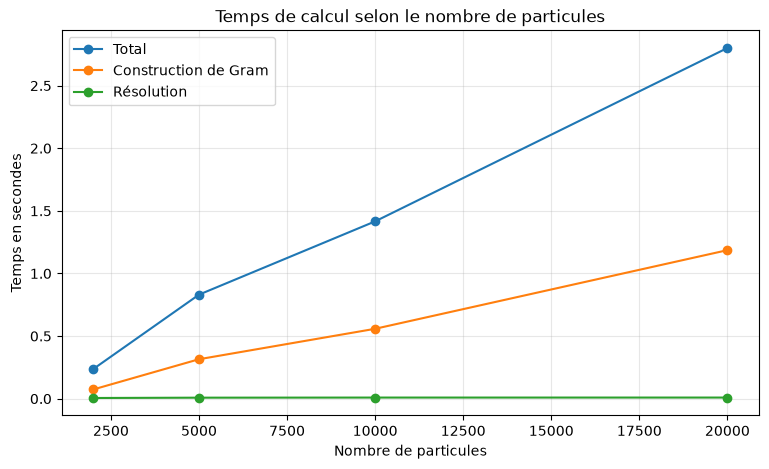

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    benchmark_n["n_particles"],
    benchmark_n["total_runtime"],
    marker="o",
    label="Total",
)

plt.plot(
    benchmark_n["n_particles"],
    benchmark_n["gram_time"],
    marker="o",
    label="Construction de Gram",
)

plt.plot(
    benchmark_n["n_particles"],
    benchmark_n["solve_time"],
    marker="o",
    label="Résolution",
)

plt.xlabel("Nombre de particules")
plt.ylabel("Temps en secondes")
plt.title("Temps de calcul selon le nombre de particules")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Benchmark in RKHS

In [27]:
def benchmark_centre_counts(
    centre_counts,
    model,
    base_rkhs,
    simulation,
    market,
):
    records = []

    for n_centres in centre_counts:
        print(f"Simulation avec L = {n_centres}")

        rkhs = replace(
            base_rkhs,
            n_centres=n_centres,
        )

        result = simulate_calibrated_sir_lsv(
            model=model,
            rkhs=rkhs,
            simulation=simulation,
            market=market,
        )

        timings = result.timing_history

        records.append(
            {
                "n_centres": n_centres,
                "total_runtime": result.total_runtime,
                "gram_time": timings[
                    "gram_construction"
                ].sum(),
                "solve_time": timings[
                    "linear_solve"
                ].sum(),
                "mean_condition_number": timings[
                    "condition_number"
                ].mean(),
                "max_condition_number": timings[
                    "condition_number"
                ].max(),
                "mean_leverage": (
                    result.leverage_history[
                        "leverage"
                    ].mean()
                ),
                "max_leverage": (
                    result.leverage_history[
                        "leverage"
                    ].max()
                ),
            }
        )

    return pd.DataFrame(records)


benchmark_l = benchmark_centre_counts(
    centre_counts=[8, 16, 32, 64],
    model=model_params,
    base_rkhs=rkhs_params,
    simulation=replace(
        simulation_params,
        n_particles=10_000,
    ),
    market=market,
)

benchmark_l

Simulation avec L = 8
Simulation avec L = 16
Simulation avec L = 32
Simulation avec L = 64


,n_centres,total_runtime,gram_time,solve_time,mean_condition_number,max_condition_number,mean_leverage,max_leverage
0,8,0.348382,0.085026,0.005869,1244.338428,113256.662624,1.326455,2.215825
1,16,0.883409,0.305310,0.008694,20338.994778,438788.965199,1.340351,2.379242
2,32,1.439311,0.559039,0.009464,229314.266255,713788.113598,1.345357,2.502447
3,64,2.554571,1.038674,0.009161,246649.258216,774756.141126,1.348856,2.810486


# Imports 2

In [28]:
from dataclasses import dataclass, replace
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq
from scipy.signal import savgol_filter

# Simulating a market

In [29]:
@dataclass(frozen=True)
class ReferenceMarketConfiguration:
    maturity: float = 1.0

    # Première exécution raisonnable.
    # On augmentera ensuite vers 500_000 particules.
    n_particles: int = 100_000
    n_steps: int = 250
    n_snapshots: int = 21

    strike_min: float = 0.50
    strike_max: float = 1.60
    n_strikes: int = 61

    seed: int = 12345
    chunk_size: int = 10_000

    # Bandwidth de l'estimateur de référence
    bandwidth_scale: float = 0.50
    minimum_bandwidth: float = 5e-4

    minimum_effective_sample_size: float = 100.0
    density_relative_floor: float = 1e-6


@dataclass
class RawSIRHestonMarket:
    times: np.ndarray
    domestic_discount_curve: np.ndarray
    foreign_discount_curve: np.ndarray

    domestic_forward_rates: np.ndarray
    foreign_forward_rates: np.ndarray

    snapshots: dict
    runtime: float

In [30]:
def smooth_log_discount_curve(
    discount_curve: np.ndarray,
    times: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    discount_curve = np.maximum(
        np.asarray(discount_curve, dtype=float),
        1e-12,
    )

    log_discount = np.log(discount_curve)

    n_points = discount_curve.size

    # Plus grande fenêtre impaire raisonnable
    window = min(31, n_points)

    if window % 2 == 0:
        window -= 1

    if window >= 7:
        smoothed_log_discount = savgol_filter(
            log_discount,
            window_length=window,
            polyorder=3,
            mode="interp",
        )
    else:
        smoothed_log_discount = log_discount

    smoothed_discount = np.exp(
        smoothed_log_discount
    )

    instantaneous_forward_rate = -np.gradient(
        smoothed_log_discount,
        times,
        edge_order=2,
    )

    return (
        smoothed_discount,
        instantaneous_forward_rate,
    )

In [31]:
def simulate_reference_sir_heston(
    model: SIRLSVParameters,
    config: ReferenceMarketConfiguration,
) -> RawSIRHestonMarket:
    start_total = time.perf_counter()

    if config.n_particles % 2 != 0:
        raise ValueError(
            "n_particles doit être pair pour utiliser "
            "les variables antithétiques."
        )

    rng = np.random.default_rng(config.seed)

    n = config.n_particles
    n_half = n // 2

    dt = config.maturity / config.n_steps
    sqrt_dt = np.sqrt(dt)

    times = np.linspace(
        0.0,
        config.maturity,
        config.n_steps + 1,
    )

    correlation = correlation_matrix(model)
    cholesky = np.linalg.cholesky(correlation)

    # États initiaux
    spot = np.full(n, model.s0, dtype=float)
    variance = np.full(n, model.v0, dtype=float)

    gd0 = max(
        model.rd0 - model.h_d(0.0),
        0.0,
    )

    gf0 = max(
        model.rf0 - model.h_f(0.0),
        0.0,
    )

    gd = np.full(n, gd0, dtype=float)
    gf = np.full(n, gf0, dtype=float)

    domestic_rate = gd + model.h_d(0.0)
    foreign_rate = gf + model.h_f(0.0)

    domestic_discount = np.ones(n, dtype=float)

    domestic_discount_curve = np.empty(
        config.n_steps + 1
    )

    foreign_discount_curve = np.empty(
        config.n_steps + 1
    )

    domestic_discount_curve[0] = 1.0
    foreign_discount_curve[0] = 1.0

    # Dates auxquelles les particules sont conservées
    regular_snapshot_steps = np.linspace(
        1,
        config.n_steps,
        config.n_snapshots,
        dtype=int,
    )

    snapshot_steps = np.unique(
        np.concatenate(
            [
                np.array([1], dtype=int),
                regular_snapshot_steps,
            ]
        )
    )

    snapshots = {}

    var_params = model.variance
    rd_params = model.domestic_rate
    rf_params = model.foreign_rate

    for step in range(1, config.n_steps + 1):
        current_time = step * dt

        # Variables antithétiques
        independent_half = rng.standard_normal(
            (n_half, 4)
        )

        independent_normals = np.vstack(
            [
                independent_half,
                -independent_half,
            ]
        )

        correlated_normals = (
            independent_normals @ cholesky.T
        )

        z_s = correlated_normals[:, 0]
        z_d = correlated_normals[:, 1]
        z_f = correlated_normals[:, 2]
        z_v = correlated_normals[:, 3]

        variance_positive = np.maximum(
            variance,
            0.0,
        )

        gd_positive = np.maximum(gd, 0.0)
        gf_positive = np.maximum(gf, 0.0)

        old_domestic_rate = domestic_rate.copy()
        old_foreign_rate = foreign_rate.copy()

        # Spot avec leverage vraie L = 1
        spot = (
            spot
            + (old_domestic_rate - old_foreign_rate)
            * spot
            * dt
            + np.sqrt(variance_positive)
            * spot
            * sqrt_dt
            * z_s
        )

        spot = np.maximum(spot, 1e-10)

        # Discount factor domestique
        domestic_discount *= np.exp(
            -old_domestic_rate * dt
        )

        # Taux domestique
        gd = (
            gd
            + rd_params.kappa
            * (rd_params.theta - gd_positive)
            * dt
            + rd_params.xi
            * np.sqrt(gd_positive)
            * sqrt_dt
            * z_d
        )

        gd = np.maximum(gd, 0.0)

        # Ajustement quanto du taux étranger
        foreign_quanto_drift = (
            -model.rho_sf
            * rf_params.xi
            * np.sqrt(gf_positive)
            * np.sqrt(variance_positive)
        )

        gf = (
            gf
            + (
                rf_params.kappa
                * (rf_params.theta - gf_positive)
                + foreign_quanto_drift
            )
            * dt
            + rf_params.xi
            * np.sqrt(gf_positive)
            * sqrt_dt
            * z_f
        )

        gf = np.maximum(gf, 0.0)

        # Variance
        variance = (
            variance
            + var_params.kappa
            * (
                var_params.theta
                - variance_positive
            )
            * dt
            + var_params.xi
            * np.sqrt(variance_positive)
            * sqrt_dt
            * z_v
        )

        variance = np.maximum(variance, 0.0)

        domestic_rate = (
            gd + model.h_d(current_time)
        )

        foreign_rate = (
            gf + model.h_f(current_time)
        )

        # Courbe domestique
        domestic_discount_curve[step] = (
            domestic_discount.mean()
        )

        # S0 Pf(0,T) = E[Dd(T) S(T)]
        foreign_discount_curve[step] = (
            np.mean(domestic_discount * spot)
            / model.s0
        )

        if step in snapshot_steps:
            snapshots[step] = {
                "time": current_time,
                "spot": spot.copy(),
                "variance": variance.copy(),
                "domestic_rate": (
                    domestic_rate.copy()
                ),
                "foreign_rate": (
                    foreign_rate.copy()
                ),
                "domestic_discount": (
                    domestic_discount.copy()
                ),
            }

    (
        domestic_discount_curve,
        domestic_forward_rates,
    ) = smooth_log_discount_curve(
        domestic_discount_curve,
        times,
    )

    (
        foreign_discount_curve,
        foreign_forward_rates,
    ) = smooth_log_discount_curve(
        foreign_discount_curve,
        times,
    )

    runtime = time.perf_counter() - start_total

    return RawSIRHestonMarket(
        times=times,
        domestic_discount_curve=(
            domestic_discount_curve
        ),
        foreign_discount_curve=(
            foreign_discount_curve
        ),
        domestic_forward_rates=(
            domestic_forward_rates
        ),
        foreign_forward_rates=(
            foreign_forward_rates
        ),
        snapshots=snapshots,
        runtime=runtime,
    )

In [32]:
def garman_kohlhagen_price(
    s0: float,
    strike: float,
    maturity: float,
    volatility: float,
    domestic_discount: float,
    foreign_discount: float,
    option_type: str,
) -> float:
    if maturity <= 0:
        if option_type == "call":
            return max(s0 - strike, 0.0)
        return max(strike - s0, 0.0)

    volatility = max(volatility, 1e-12)

    forward = (
        s0
        * foreign_discount
        / domestic_discount
    )

    vol_sqrt_t = volatility * np.sqrt(maturity)

    d1 = (
        np.log(forward / strike)
        + 0.5 * volatility**2 * maturity
    ) / vol_sqrt_t

    d2 = d1 - vol_sqrt_t

    if option_type == "call":
        return (
            s0
            * foreign_discount
            * norm.cdf(d1)
            - strike
            * domestic_discount
            * norm.cdf(d2)
        )

    if option_type == "put":
        return (
            strike
            * domestic_discount
            * norm.cdf(-d2)
            - s0
            * foreign_discount
            * norm.cdf(-d1)
        )

    raise ValueError(
        "option_type doit être 'call' ou 'put'."
    )


def implied_volatility_fx(
    price: float,
    s0: float,
    strike: float,
    maturity: float,
    domestic_discount: float,
    foreign_discount: float,
    option_type: str,
) -> float:
    if maturity <= 0:
        return np.nan

    forward = (
        s0
        * foreign_discount
        / domestic_discount
    )

    if option_type == "call":
        intrinsic = max(
            s0 * foreign_discount
            - strike * domestic_discount,
            0.0,
        )
        upper_bound = s0 * foreign_discount
    else:
        intrinsic = max(
            strike * domestic_discount
            - s0 * foreign_discount,
            0.0,
        )
        upper_bound = strike * domestic_discount

    time_value = price - intrinsic

    # Prix trop proche de la borne d'arbitrage :
    # IV non identifiable avec précision
    if time_value <= 1e-10:
        return np.nan

    if price >= upper_bound - 1e-12:
        return np.nan

    def objective(volatility):
        return (
            garman_kohlhagen_price(
                s0=s0,
                strike=strike,
                maturity=maturity,
                volatility=volatility,
                domestic_discount=domestic_discount,
                foreign_discount=foreign_discount,
                option_type=option_type,
            )
            - price
        )

    try:
        return brentq(
            objective,
            1e-6,
            5.0,
            maxiter=200,
        )
    except ValueError:
        return np.nan

In [33]:
def process_reference_snapshot(
    snapshot: dict,
    strikes: np.ndarray,
    s0: float,
    domestic_discount_zero: float,
    foreign_discount_zero: float,
    domestic_forward_rate: float,
    foreign_forward_rate: float,
    config: ReferenceMarketConfiguration,
):
    spot = snapshot["spot"]
    variance = snapshot["variance"]
    domestic_rate = snapshot["domestic_rate"]
    foreign_rate = snapshot["foreign_rate"]
    domestic_discount = snapshot[
        "domestic_discount"
    ]

    maturity = snapshot["time"]
    n_particles = spot.size

    empirical_std = np.std(spot, ddof=1)

    silverman_bandwidth = (
        1.06
        * empirical_std
        * n_particles ** (-1.0 / 5.0)
    )

    bandwidth = max(
        config.bandwidth_scale
        * silverman_bandwidth,
        config.minimum_bandwidth,
    )

    n_strikes = strikes.size

    call_sum = np.zeros(n_strikes)
    put_sum = np.zeros(n_strikes)

    weighted_kernel_sum = np.zeros(n_strikes)
    weighted_kernel_square_sum = np.zeros(
        n_strikes
    )

    weighted_variance_kernel_sum = np.zeros(
        n_strikes
    )

    rate_correction_sum = np.zeros(n_strikes)

    normalization = (
        np.sqrt(2.0 * np.pi) * bandwidth
    )

    for start in range(
        0,
        n_particles,
        config.chunk_size,
    ):
        stop = min(
            start + config.chunk_size,
            n_particles,
        )

        s = spot[start:stop, None]
        v = variance[start:stop, None]

        rd = domestic_rate[start:stop, None]
        rf = foreign_rate[start:stop, None]

        discount = domestic_discount[
            start:stop, None
        ]

        k = strikes[None, :]

        call_sum += np.sum(
            discount * np.maximum(s - k, 0.0),
            axis=0,
        )

        put_sum += np.sum(
            discount * np.maximum(k - s, 0.0),
            axis=0,
        )

        kernel = np.exp(
            -0.5 * ((s - k) / bandwidth) ** 2
        ) / normalization

        weighted_kernel = discount * kernel

        weighted_kernel_sum += np.sum(
            weighted_kernel,
            axis=0,
        )

        weighted_kernel_square_sum += np.sum(
            weighted_kernel**2,
            axis=0,
        )

        weighted_variance_kernel_sum += np.sum(
            weighted_kernel * v,
            axis=0,
        )

        payoff = np.maximum(s - k, 0.0)
        indicator = s >= k

        q = (
            discount
            * (rf - foreign_forward_rate)
            * payoff
            - k
            * discount
            * indicator
            * (
                (rd - domestic_forward_rate)
                - (rf - foreign_forward_rate)
            )
        )

        rate_correction_sum += np.sum(
            q,
            axis=0,
        )

    call_prices = call_sum / n_particles
    put_prices = put_sum / n_particles

    call_gamma = (
        weighted_kernel_sum / n_particles
    )

    conditional_discounted_variance_ratio = (
        weighted_variance_kernel_sum
        / np.maximum(
            weighted_kernel_sum,
            1e-16,
        )
    )

    rate_correction = (
        rate_correction_sum / n_particles
    )

    effective_sample_size = (
        weighted_kernel_sum**2
        / np.maximum(
            weighted_kernel_square_sum,
            1e-16,
        )
    )

    denominator = (
        0.5
        * strikes**2
        * call_gamma
    )

    dupire_variance = (
        conditional_discounted_variance_ratio
        - rate_correction
        / np.maximum(denominator, 1e-16)
    )

    density_threshold = (
        config.density_relative_floor
        * np.max(call_gamma)
    )

    valid = (
        np.isfinite(dupire_variance)
        & (dupire_variance > 0.0)
        & (call_gamma > density_threshold)
        & (
            effective_sample_size
            >= config.minimum_effective_sample_size
        )
    )

    if valid.sum() < 3:
        raise RuntimeError(
            f"Pas assez de strikes valides à T={maturity:.4f}. "
            f"Nombre de points valides : {valid.sum()}."
        )

    # Extrapolation constante dans les queues
    dupire_variance_filled = np.interp(
        strikes,
        strikes[valid],
        dupire_variance[valid],
    )

    dupire_volatility = np.sqrt(
        np.maximum(
            dupire_variance_filled,
            1e-10,
        )
    )

    forward = (
        s0
        * foreign_discount_zero
        / domestic_discount_zero
    )

    implied_volatilities = np.empty(n_strikes)
    option_types = []

    for j, strike in enumerate(strikes):
        # OTM pour une inversion plus stable
        if strike >= forward:
            option_type = "call"
            price = call_prices[j]
        else:
            option_type = "put"
            price = put_prices[j]

        option_types.append(option_type)

        implied_volatilities[j] = (
            implied_volatility_fx(
                price=price,
                s0=s0,
                strike=strike,
                maturity=maturity,
                domestic_discount=(
                    domestic_discount_zero
                ),
                foreign_discount=(
                    foreign_discount_zero
                ),
                option_type=option_type,
            )
        )

    return {
        "maturity": maturity,
        "bandwidth": bandwidth,
        "forward": forward,
        "call_prices": call_prices,
        "put_prices": put_prices,
        "implied_volatilities": (
            implied_volatilities
        ),
        "option_types": option_types,
        "call_gamma": call_gamma,
        "conditional_variance": (
            conditional_discounted_variance_ratio
        ),
        "rate_correction": rate_correction,
        "dupire_volatility": dupire_volatility,
        "effective_sample_size": (
            effective_sample_size
        ),
        "valid_mask": valid,
    }

In [34]:
@dataclass
class ReferenceSIRHestonMarket:
    s0: float

    times: np.ndarray
    strikes: np.ndarray

    dupire_surface: np.ndarray
    gamma_surface: np.ndarray
    implied_volatility_surface: np.ndarray

    domestic_discount_curve: np.ndarray
    foreign_discount_curve: np.ndarray

    domestic_forward_rates: np.ndarray
    foreign_forward_rates: np.ndarray

    price_table: pd.DataFrame
    diagnostics_table: pd.DataFrame

    def __post_init__(self):
        self._dupire_interpolator = (
            RegularGridInterpolator(
                (self.times, self.strikes),
                self.dupire_surface,
                bounds_error=False,
                fill_value=None,
            )
        )

        self._gamma_interpolator = (
            RegularGridInterpolator(
                (self.times, self.strikes),
                self.gamma_surface,
                bounds_error=False,
                fill_value=None,
            )
        )

    def _evaluate_surface(
        self,
        interpolator,
        t,
        x,
    ):
        x_array = np.asarray(x, dtype=float)
        original_shape = x_array.shape

        flat_x = x_array.ravel()

        clipped_time = np.clip(
            float(t),
            self.times[0],
            self.times[-1],
        )

        clipped_x = np.clip(
            flat_x,
            self.strikes[0],
            self.strikes[-1],
        )

        points = np.column_stack(
            [
                np.full(flat_x.size, clipped_time),
                clipped_x,
            ]
        )

        values = interpolator(points).reshape(
            original_shape
        )

        if np.isscalar(x):
            return float(values)

        return values

    def sigma_dupire(self, t, x):
        return self._evaluate_surface(
            self._dupire_interpolator,
            t,
            x,
        )

    def call_strike_gamma(self, t, x):
        values = self._evaluate_surface(
            self._gamma_interpolator,
            t,
            x,
        )

        return np.maximum(values, 1e-12)

    def rd_bar(self, t):
        return float(
            np.interp(
                t,
                self.times,
                self.domestic_forward_rates,
            )
        )

    def rf_bar(self, t):
        return float(
            np.interp(
                t,
                self.times,
                self.foreign_forward_rates,
            )
        )

In [35]:
def build_reference_market(
    raw_market: RawSIRHestonMarket,
    model: SIRLSVParameters,
    config: ReferenceMarketConfiguration,
) -> ReferenceSIRHestonMarket:
    strikes = np.linspace(
        config.strike_min * model.s0,
        config.strike_max * model.s0,
        config.n_strikes,
    )

    snapshot_steps = sorted(
        raw_market.snapshots.keys()
    )

    snapshot_times = np.array(
        [
            raw_market.snapshots[step]["time"]
            for step in snapshot_steps
        ]
    )

    results = []

    for step in snapshot_steps:
        snapshot = raw_market.snapshots[step]
        maturity = snapshot["time"]

        domestic_discount_zero = np.interp(
            maturity,
            raw_market.times,
            raw_market.domestic_discount_curve,
        )

        foreign_discount_zero = np.interp(
            maturity,
            raw_market.times,
            raw_market.foreign_discount_curve,
        )

        domestic_forward_rate = np.interp(
            maturity,
            raw_market.times,
            raw_market.domestic_forward_rates,
        )

        foreign_forward_rate = np.interp(
            maturity,
            raw_market.times,
            raw_market.foreign_forward_rates,
        )

        result = process_reference_snapshot(
            snapshot=snapshot,
            strikes=strikes,
            s0=model.s0,
            domestic_discount_zero=(
                domestic_discount_zero
            ),
            foreign_discount_zero=(
                foreign_discount_zero
            ),
            domestic_forward_rate=(
                domestic_forward_rate
            ),
            foreign_forward_rate=(
                foreign_forward_rate
            ),
            config=config,
        )

        results.append(result)

        print(
            f"T={maturity:.4f} | "
            f"h={result['bandwidth']:.6f} | "
            f"valid={result['valid_mask'].sum()}"
            f"/{strikes.size}"
        )

    dupire_surface = np.vstack(
        [
            result["dupire_volatility"]
            for result in results
        ]
    )

    gamma_surface = np.vstack(
        [
            result["call_gamma"]
            for result in results
        ]
    )

    implied_volatility_surface = np.vstack(
        [
            result["implied_volatilities"]
            for result in results
        ]
    )

    price_records = []
    diagnostic_records = []

    for result in results:
        maturity = result["maturity"]

        for j, strike in enumerate(strikes):
            price_records.append(
                {
                    "maturity": maturity,
                    "strike": strike,
                    "forward": result["forward"],
                    "call_price": (
                        result["call_prices"][j]
                    ),
                    "put_price": (
                        result["put_prices"][j]
                    ),
                    "option_type_used": (
                        result["option_types"][j]
                    ),
                    "implied_volatility": (
                        result[
                            "implied_volatilities"
                        ][j]
                    ),
                    "dupire_volatility": (
                        result["dupire_volatility"][j]
                    ),
                    "call_gamma": (
                        result["call_gamma"][j]
                    ),
                    "effective_sample_size": (
                        result[
                            "effective_sample_size"
                        ][j]
                    ),
                    "valid_dupire_point": bool(
                        result["valid_mask"][j]
                    ),
                }
            )

        diagnostic_records.append(
            {
                "maturity": maturity,
                "bandwidth": result["bandwidth"],
                "forward": result["forward"],
                "valid_points": int(
                    result["valid_mask"].sum()
                ),
                "min_dupire_vol": np.min(
                    result["dupire_volatility"]
                ),
                "max_dupire_vol": np.max(
                    result["dupire_volatility"]
                ),
                "min_implied_vol": np.nanmin(
                    result["implied_volatilities"]
                ),
                "max_implied_vol": np.nanmax(
                    result["implied_volatilities"]
                ),
            }
        )

    domestic_discount_snapshot = np.interp(
        snapshot_times,
        raw_market.times,
        raw_market.domestic_discount_curve,
    )

    foreign_discount_snapshot = np.interp(
        snapshot_times,
        raw_market.times,
        raw_market.foreign_discount_curve,
    )

    domestic_forward_snapshot = np.interp(
        snapshot_times,
        raw_market.times,
        raw_market.domestic_forward_rates,
    )

    foreign_forward_snapshot = np.interp(
        snapshot_times,
        raw_market.times,
        raw_market.foreign_forward_rates,
    )

    return ReferenceSIRHestonMarket(
        s0=model.s0,
        times=snapshot_times,
        strikes=strikes,
        dupire_surface=dupire_surface,
        gamma_surface=gamma_surface,
        implied_volatility_surface=(
            implied_volatility_surface
        ),
        domestic_discount_curve=(
            domestic_discount_snapshot
        ),
        foreign_discount_curve=(
            foreign_discount_snapshot
        ),
        domestic_forward_rates=(
            domestic_forward_snapshot
        ),
        foreign_forward_rates=(
            foreign_forward_snapshot
        ),
        price_table=pd.DataFrame(price_records),
        diagnostics_table=pd.DataFrame(
            diagnostic_records
        ),
    )

In [36]:
reference_config = ReferenceMarketConfiguration(
    maturity=1.0,
    n_particles=100_000,
    n_steps=250,
    n_snapshots=21,
    n_strikes=61,
    seed=12345,
)

raw_reference_market = simulate_reference_sir_heston(
    model=model_params,
    config=reference_config,
)

print(
    f"Temps de simulation du marché : "
    f"{raw_reference_market.runtime:.2f} secondes"
)

reference_market = build_reference_market(
    raw_market=raw_reference_market,
    model=model_params,
    config=reference_config,
)

print(reference_market.diagnostics_table)

Temps de simulation du marché : 2.00 secondes
T=0.0040 | h=0.001061 | valid=6/61
T=0.0520 | h=0.003805 | valid=23/61
T=0.1000 | h=0.005159 | valid=31/61
T=0.1520 | h=0.006237 | valid=38/61
T=0.2000 | h=0.007049 | valid=43/61
T=0.2520 | h=0.007791 | valid=47/61
T=0.3000 | h=0.008384 | valid=49/61
T=0.3520 | h=0.008980 | valid=53/61
T=0.4000 | h=0.009454 | valid=54/61
T=0.4520 | h=0.009935 | valid=55/61
T=0.5000 | h=0.010340 | valid=57/61
T=0.5480 | h=0.010712 | valid=57/61
T=0.6000 | h=0.011095 | valid=59/61
T=0.6480 | h=0.011416 | valid=60/61
T=0.7000 | h=0.011730 | valid=61/61
T=0.7480 | h=0.012020 | valid=61/61
T=0.8000 | h=0.012305 | valid=61/61
T=0.8480 | h=0.012565 | valid=61/61
T=0.9000 | h=0.012839 | valid=61/61
T=0.9480 | h=0.013075 | valid=61/61
T=1.0000 | h=0.013333 | valid=61/61
    maturity  bandwidth   forward  valid_points  min_dupire_vol  \
0      0.004   0.001061  1.000047             6        0.286558   
1      0.052   0.003805  1.000514            23        0.218038  

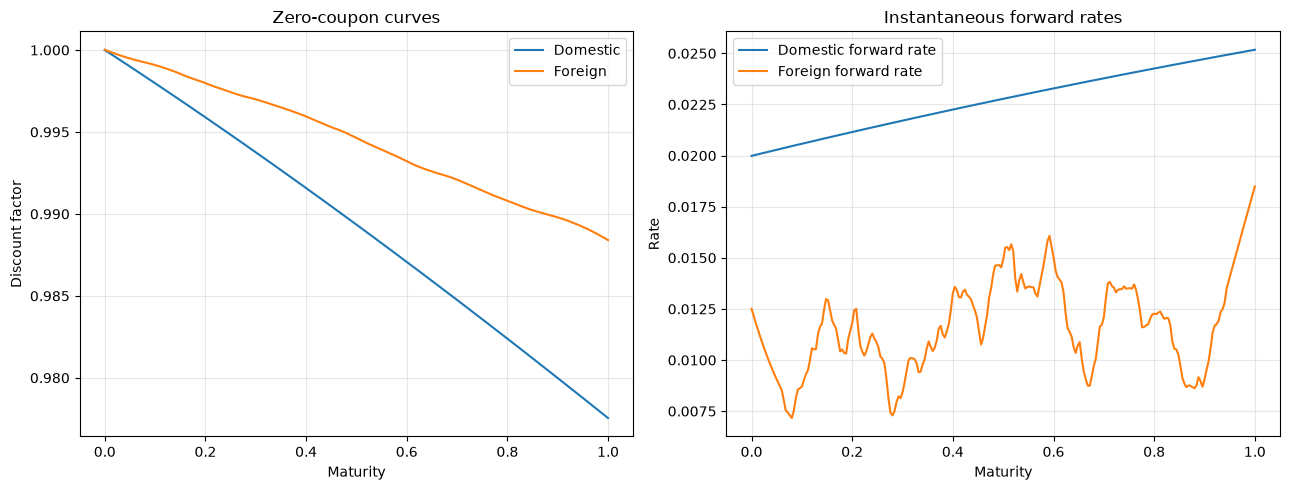

In [37]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].plot(
    raw_reference_market.times,
    raw_reference_market.domestic_discount_curve,
    label="Domestic",
)

axes[0].plot(
    raw_reference_market.times,
    raw_reference_market.foreign_discount_curve,
    label="Foreign",
)

axes[0].set_title("Zero-coupon curves")
axes[0].set_xlabel("Maturity")
axes[0].set_ylabel("Discount factor")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    raw_reference_market.times,
    raw_reference_market.domestic_forward_rates,
    label="Domestic forward rate",
)

axes[1].plot(
    raw_reference_market.times,
    raw_reference_market.foreign_forward_rates,
    label="Foreign forward rate",
)

axes[1].set_title("Instantaneous forward rates")
axes[1].set_xlabel("Maturity")
axes[1].set_ylabel("Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

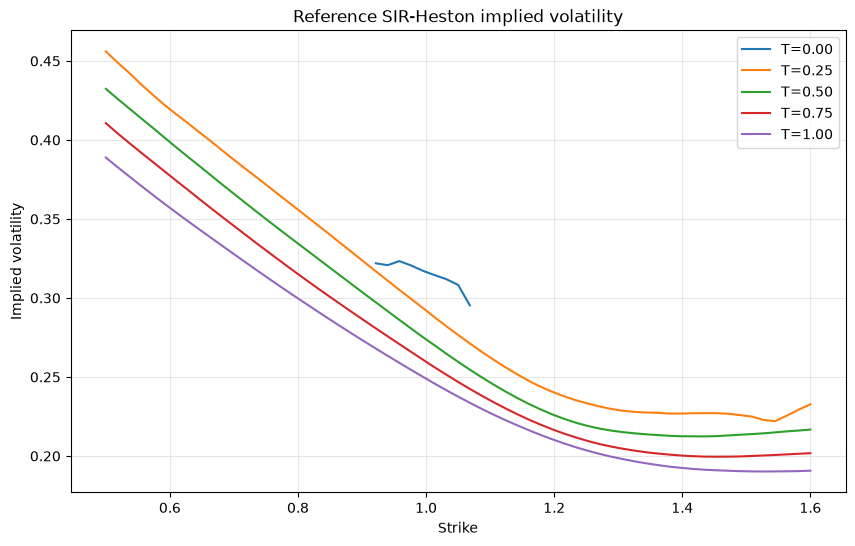

In [38]:
plt.figure(figsize=(10, 6))

selected_indices = np.linspace(
    0,
    len(reference_market.times) - 1,
    5,
    dtype=int,
)

for index in selected_indices:
    plt.plot(
        reference_market.strikes,
        reference_market.implied_volatility_surface[
            index
        ],
        label=(
            f"T={reference_market.times[index]:.2f}"
        ),
    )

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title("Reference SIR-Heston implied volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

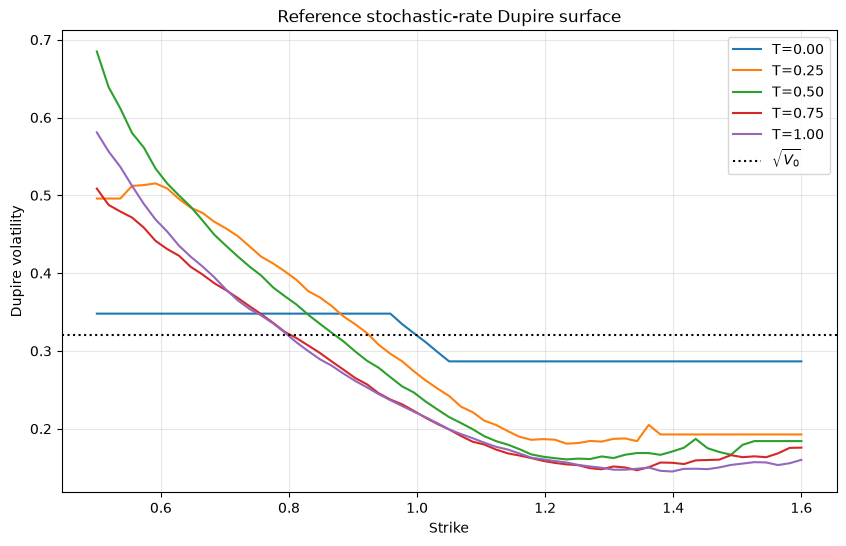

In [39]:
plt.figure(figsize=(10, 6))

for index in selected_indices:
    plt.plot(
        reference_market.strikes,
        reference_market.dupire_surface[index],
        label=(
            f"T={reference_market.times[index]:.2f}"
        ),
    )

plt.axhline(
    np.sqrt(model_params.v0),
    color="black",
    linestyle=":",
    label=r"$\sqrt{V_0}$",
)

plt.xlabel("Strike")
plt.ylabel("Dupire volatility")
plt.title("Reference stochastic-rate Dupire surface")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
def locate_surface_extrema(reference_market):
    table = reference_market.price_table.copy()

    minima = (
        table.loc[
            table.groupby("maturity")[
                "dupire_volatility"
            ].idxmin()
        ]
        [
            [
                "maturity",
                "strike",
                "forward",
                "dupire_volatility",
                "implied_volatility",
                "call_gamma",
                "effective_sample_size",
                "valid_dupire_point",
            ]
        ]
        .rename(
            columns={
                "strike": "min_vol_strike",
                "dupire_volatility": "min_dupire_vol",
                "effective_sample_size": "min_point_ess",
                "valid_dupire_point": "min_point_valid",
            }
        )
    )

    maxima = (
        table.loc[
            table.groupby("maturity")[
                "dupire_volatility"
            ].idxmax()
        ]
        [
            [
                "maturity",
                "strike",
                "dupire_volatility",
                "implied_volatility",
                "call_gamma",
                "effective_sample_size",
                "valid_dupire_point",
            ]
        ]
        .rename(
            columns={
                "strike": "max_vol_strike",
                "dupire_volatility": "max_dupire_vol",
                "effective_sample_size": "max_point_ess",
                "valid_dupire_point": "max_point_valid",
            }
        )
    )

    return minima.merge(
        maxima,
        on="maturity",
        suffixes=("_min", "_max"),
    )


surface_extrema = locate_surface_extrema(
    reference_market
)

surface_extrema

,maturity,min_vol_strike,forward,min_dupire_vol,implied_volatility_min,call_gamma_min,min_point_ess,min_point_valid,max_vol_strike,max_dupire_vol,implied_volatility_max,call_gamma_max,max_point_ess,max_point_valid
0,0.004,1.050000,1.000047,0.286558,0.308272,0.841203,326.486159,True,0.500000,0.347915,NaN,0.000000,0.000000,False
1,0.052,1.178333,1.000514,0.218038,0.268709,0.159062,220.616736,True,0.811667,0.411986,0.372419,0.236891,326.239112,True
2,0.100,1.215000,1.001110,0.207681,0.255029,0.273791,513.403706,True,0.756667,0.428807,0.379687,0.238292,434.811758,True
3,0.152,1.288333,1.001627,0.194255,0.239017,0.089572,200.894301,True,0.500000,0.709250,0.466016,0.001444,2.548089,False
4,0.200,1.233333,1.002097,0.187976,0.239918,0.559087,1404.718925,True,0.500000,0.666661,0.447084,0.008743,21.833178,False
5,0.252,1.233333,1.002627,0.180813,0.235340,0.740692,2041.004373,True,0.591667,0.515323,0.422097,0.115068,308.181497,True
6,0.300,0.500000,1.003252,0.115334,0.452527,0.036230,117.364091,False,0.665000,0.429530,0.394377,0.307449,925.827952,True
7,0.352,1.251667,1.003881,0.173119,0.227033,0.764351,2436.456347,True,0.518333,0.509137,0.443614,0.082975,266.459688,True
8,0.400,1.233333,1.004402,0.167317,0.225477,1.055180,3566.963282,True,0.500000,0.664347,0.442740,0.098204,323.746274,True
9,0.452,1.233333,1.004892,0.161350,0.223461,1.099546,3924.979828,True,0.500000,0.511998,0.437273,0.109359,388.558343,True


In [41]:
def check_reference_market_arbitrage(
    reference_market,
):
    records = []

    for maturity, data in (
        reference_market.price_table
        .groupby("maturity")
    ):
        data = data.sort_values("strike")

        strikes = data["strike"].to_numpy()
        calls = data["call_price"].to_numpy()
        puts = data["put_price"].to_numpy()

        domestic_discount = np.interp(
            maturity,
            reference_market.times,
            reference_market.domestic_discount_curve,
        )

        foreign_discount = np.interp(
            maturity,
            reference_market.times,
            reference_market.foreign_discount_curve,
        )

        parity_rhs = (
            reference_market.s0
            * foreign_discount
            - strikes * domestic_discount
        )

        parity_error = (
            calls - puts - parity_rhs
        )

        first_difference = np.diff(calls)

        strike_steps = np.diff(strikes)

        call_slopes = (
            first_difference / strike_steps
        )

        second_difference = np.diff(
            call_slopes
        )

        records.append(
            {
                "maturity": maturity,
                "max_abs_parity_error": np.max(
                    np.abs(parity_error)
                ),
                "monotonicity_violations": int(
                    np.sum(first_difference > 1e-10)
                ),
                "convexity_violations": int(
                    np.sum(second_difference < -1e-8)
                ),
                "min_call_price": calls.min(),
                "max_call_price": calls.max(),
            }
        )

    return pd.DataFrame(records)


arbitrage_diagnostics = (
    check_reference_market_arbitrage(
        reference_market
    )
)

arbitrage_diagnostics

,maturity,max_abs_parity_error,monotonicity_violations,convexity_violations,min_call_price,max_call_price
0,0.004,0.000007,0,0,0.000000,0.500000
1,0.052,0.000015,0,0,0.000000,0.499975
2,0.100,0.000035,0,0,0.000000,0.500130
3,0.152,0.000009,0,0,0.000000,0.500082
4,0.200,0.000039,0,0,0.000000,0.500006
5,0.252,0.000033,0,0,0.000001,0.500029
6,0.300,0.000012,0,0,0.000002,0.500253
7,0.352,0.000008,0,0,0.000008,0.500445
8,0.400,0.000022,0,0,0.000019,0.500578
9,0.452,0.000001,0,0,0.000042,0.500658


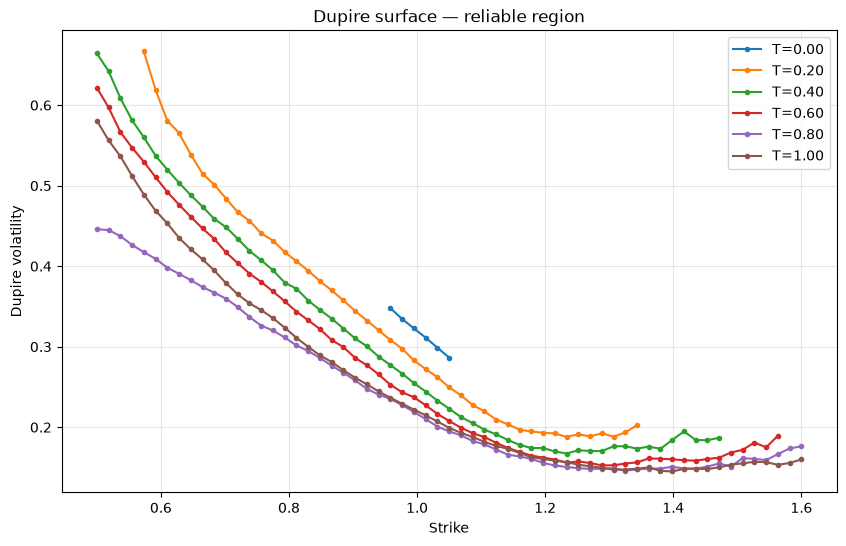

In [42]:
plt.figure(figsize=(10, 6))

for maturity in reference_market.times[::4]:
    data = reference_market.price_table[
        np.isclose(
            reference_market.price_table["maturity"],
            maturity,
        )
    ]

    valid = data["valid_dupire_point"]

    plt.plot(
        data.loc[valid, "strike"],
        data.loc[valid, "dupire_volatility"],
        marker="o",
        markersize=3,
        label=f"T={maturity:.2f}",
    )

plt.xlabel("Strike")
plt.ylabel("Dupire volatility")
plt.title("Dupire surface — reliable region")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [43]:
calibration_simulation = SimulationParameters(
    maturity=1.0,
    n_steps=100,
    n_particles=10_000,
    seed=2026,
    include_rate_correction=True,
)

calibrated_result = simulate_calibrated_sir_lsv(
    model=model_params,
    rkhs=rkhs_params,
    simulation=calibration_simulation,
    market=reference_market,
)

print(
    f"Calibration runtime: "
    f"{calibrated_result.total_runtime:.2f}s"
)

Calibration runtime: 1.44s


In [44]:
leverage_data = (
    calibrated_result.leverage_history.copy()
)

leverage_data["error"] = (
    leverage_data["leverage"] - 1.0
)

leverage_data["absolute_error"] = np.abs(
    leverage_data["error"]
)

leverage_data["squared_error"] = (
    leverage_data["error"] ** 2
)

leverage_recovery_metrics = pd.Series(
    {
        "mean_leverage": (
            leverage_data["leverage"].mean()
        ),
        "median_leverage": (
            leverage_data["leverage"].median()
        ),
        "min_leverage": (
            leverage_data["leverage"].min()
        ),
        "max_leverage": (
            leverage_data["leverage"].max()
        ),
        "MAE": (
            leverage_data["absolute_error"].mean()
        ),
        "RMSE": np.sqrt(
            leverage_data["squared_error"].mean()
        ),
        "max_absolute_error": (
            leverage_data["absolute_error"].max()
        ),
    }
)

print(leverage_recovery_metrics)

mean_leverage         1.000966
median_leverage       1.001176
min_leverage          0.246986
max_leverage          1.269480
MAE                   0.021097
RMSE                  0.037878
max_absolute_error    0.753014
dtype: float64


In [45]:
leverage_data = (
    calibrated_result
    .leverage_history
    .sort_values(["time", "spot"])
    .copy()
)

leverage_data["absolute_error"] = np.abs(
    leverage_data["leverage"] - 1.0
)

leverage_data["relative_position"] = (
    leverage_data
    .groupby("time")["spot"]
    .rank(pct=True)
)

lower_bound_fraction = np.mean(
    np.isclose(
        leverage_data["leverage"],
        calibration_simulation.leverage_min,
    )
)

upper_bound_fraction = np.mean(
    np.isclose(
        leverage_data["leverage"],
        calibration_simulation.leverage_max,
    )
)

print(
    f"Fraction au lower bound : "
    f"{lower_bound_fraction:.4%}"
)

print(
    f"Fraction au upper bound : "
    f"{upper_bound_fraction:.4%}"
)

display(
    leverage_data.nlargest(
        20,
        "absolute_error",
    )
)

Fraction au lower bound : 0.0000%
Fraction au upper bound : 0.0000%


,step,time,spot,leverage,raw_leverage,reliable_point,conditional_variance,sigma_dupire,call_gamma,relative_gamma,gamma_denominator,rate_correction,rate_adjustment,raw_adjusted_local_variance,absolute_error,relative_position
6208,98,0.98,0.296483,0.246986,0.246986,True,0.337010,0.534196,0.245728,0.140051,0.010800,-2.859921e-03,-0.264807,0.020558,0.753014,0.023438
6240,98,0.98,0.296483,0.246986,NaN,NaN,0.337010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.753014,0.023438
6144,97,0.97,0.294578,0.453504,0.453504,True,0.344061,0.510867,0.244396,0.139024,0.010604,-2.017106e-03,-0.190224,0.070761,0.546496,0.023438
6176,97,0.97,0.294578,0.453504,NaN,NaN,0.344061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.546496,0.023438
6080,96,0.96,0.292375,0.602772,0.602772,True,0.342970,0.487538,0.243065,0.138037,0.010389,-1.174788e-03,-0.113080,0.124613,0.397228,0.023438
6112,96,0.96,0.292375,0.602772,NaN,NaN,0.342970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.397228,0.023438
2847,45,0.45,1.445319,1.269480,1.269480,True,0.023329,0.193581,0.071038,0.030794,0.074197,9.095347e-06,0.000123,0.037596,0.269480,0.992188
2879,45,0.45,1.445319,1.269480,NaN,NaN,0.023329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.269480,0.992188
2911,46,0.46,1.451605,1.254190,1.254190,True,0.024438,0.195847,0.067072,0.029345,0.070666,5.928344e-06,0.000084,0.038440,0.254190,0.992188
2943,46,0.46,1.451605,1.254190,NaN,NaN,0.024438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.254190,0.992188


In [46]:
def leverage_metrics(data):
    error = data["leverage"] - 1.0

    return pd.Series(
        {
            "count": len(data),
            "mean_leverage": (
                data["leverage"].mean()
            ),
            "MAE": np.mean(np.abs(error)),
            "RMSE": np.sqrt(np.mean(error**2)),
            "max_absolute_error": np.max(
                np.abs(error)
            ),
        }
    )


all_metrics = leverage_metrics(
    leverage_data
)

central_90_metrics = leverage_metrics(
    leverage_data[
        leverage_data["relative_position"]
        .between(0.05, 0.95)
    ]
)

central_80_metrics = leverage_metrics(
    leverage_data[
        leverage_data["relative_position"]
        .between(0.10, 0.90)
    ]
)

pd.DataFrame(
    {
        "all_centres": all_metrics,
        "central_90%": central_90_metrics,
        "central_80%": central_80_metrics,
    }
)

,all_centres,central_90%,central_80%
count,6400.000000,5800.000000,5200.000000
mean_leverage,1.000966,1.001918,1.001933
MAE,0.021097,0.015759,0.015019
RMSE,0.037878,0.021395,0.020275
max_absolute_error,0.753014,0.110508,0.110508
